In [5]:
install.packages("censReg")
library(censReg)

also installing the dependencies 'rbibutils', 'bdsmatrix', 'collapse', 'lmtest', 'Rdpack', 'Formula', 'maxLik', 'glmmML', 'sandwich', 'miscTools', 'plm'




package 'rbibutils' successfully unpacked and MD5 sums checked
package 'bdsmatrix' successfully unpacked and MD5 sums checked
package 'collapse' successfully unpacked and MD5 sums checked
package 'lmtest' successfully unpacked and MD5 sums checked
package 'Rdpack' successfully unpacked and MD5 sums checked
package 'Formula' successfully unpacked and MD5 sums checked
package 'maxLik' successfully unpacked and MD5 sums checked
package 'glmmML' successfully unpacked and MD5 sums checked
package 'sandwich' successfully unpacked and MD5 sums checked
package 'miscTools' successfully unpacked and MD5 sums checked
package 'plm' successfully unpacked and MD5 sums checked
package 'censReg' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\jet_v\AppData\Local\Temp\Rtmp6N4MbQ\downloaded_packages


Warning message:
"package 'censReg' was built under R version 4.5.3"
Loading required package: maxLik

Warning message:
"package 'maxLik' was built under R version 4.5.3"
Loading required package: miscTools

Warning message:
"package 'miscTools' was built under R version 4.5.3"

Please cite the 'maxLik' package as:
Henningsen, Arne and Toomet, Ott (2011). maxLik: A package for maximum likelihood estimation in R. Computational Statistics 26(3), 443-458. DOI 10.1007/s00180-010-0217-1.

If you have questions, suggestions, or comments regarding the 'maxLik' package, please use a forum or 'tracker' at maxLik's R-Forge site:
https://r-forge.r-project.org/projects/maxlik/


Please cite the 'censReg' package as:
Henningsen, Arne (2017). censReg: Censored Regression (Tobit) Models. R package version 0.5. http://CRAN.R-Project.org/package=censReg.

If you have questions, suggestions, or comments regarding the 'censReg' package, please use a forum or 'tracker' at the R-Forge site of the 'sampleSe

In [1]:
d <- read.csv("Mobile_data_usage.csv", header = TRUE)
summary(d)

   CustomerID        DataUse              Quota             Days   
 Min.   :   1.0   Min.   :  0.00000   Min.   :  0.00   Min.   : 1  
 1st Qu.: 250.8   1st Qu.:  0.02548   1st Qu.: 29.11   1st Qu.: 8  
 Median : 500.5   Median :  0.53058   Median : 59.76   Median :16  
 Mean   : 500.5   Mean   :  1.66582   Mean   : 62.65   Mean   :16  
 3rd Qu.: 750.2   3rd Qu.:  1.86610   3rd Qu.: 89.91   3rd Qu.:24  
 Max.   :1000.0   Max.   :136.68000   Max.   :600.00   Max.   :31  

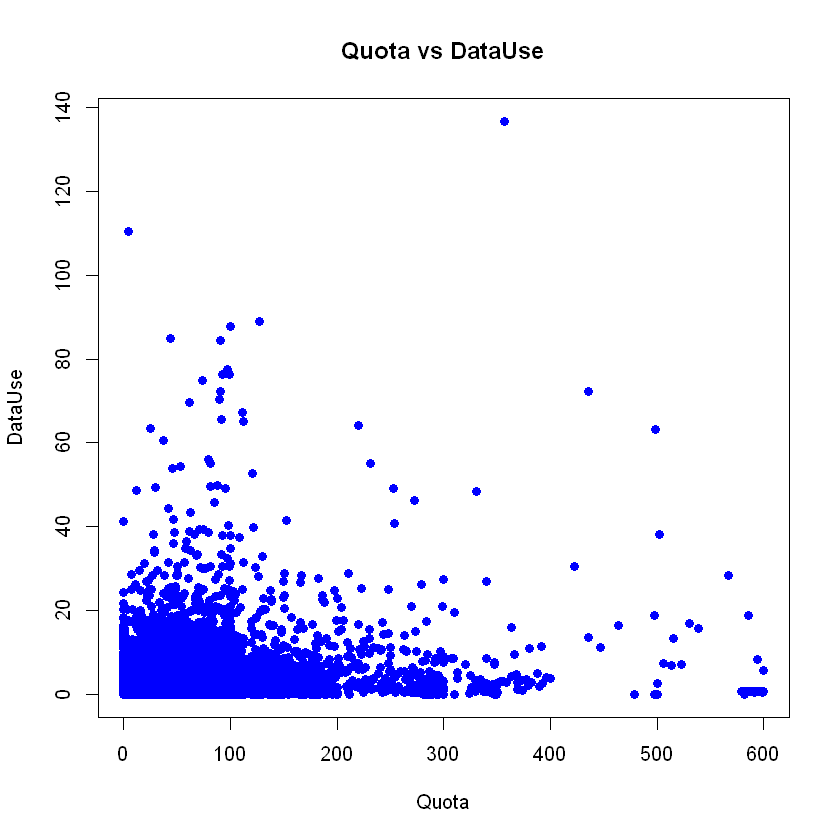

In [2]:
plot( x = d$Quota, y = d$DataUse,
     main = "Quota vs DataUse",
     xlab = "Quota", ylab = "DataUse",
     col = "blue", pch = 16
)

In [3]:
model1 <- lm(DataUse ~ Quota + Days, data = d)
summary(model1)


Call:
lm(formula = DataUse ~ Quota + Days, data = d)

Residuals:
    Min      1Q  Median      3Q     Max 
 -5.915  -1.492  -1.079   0.215 132.658 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.3633019  0.0476447  28.614  < 2e-16 ***
Quota        0.0079765  0.0004577  17.426  < 2e-16 ***
Days        -0.0123239  0.0025276  -4.876 1.09e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 3.817 on 30997 degrees of freedom
Multiple R-squared:  0.009702,	Adjusted R-squared:  0.009638 
F-statistic: 151.8 on 2 and 30997 DF,  p-value: < 2.2e-16


In [6]:
model2 <- censReg(DataUse ~ Quota + Days, left = 0, right = Inf, data = d)
summary(model2)


Call:
censReg(formula = DataUse ~ Quota + Days, left = 0, right = Inf, 
    data = d)

Observations:
         Total  Left-censored     Uncensored Right-censored 
         31000           6536          24464              0 

Coefficients:
              Estimate Std. error t value  Pr(> t)    
(Intercept)  0.6111869  0.0576965  10.593  < 2e-16 ***
Quota        0.0090140  0.0005516  16.340  < 2e-16 ***
Days        -0.0119462  0.0030650  -3.898 9.71e-05 ***
logSigma     1.4947160  0.0046189 323.611  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Newton-Raphson maximisation, 7 iterations
Return code 8: successive function values within relative tolerance limit (reltol)
Log-likelihood: -76375.86 on 4 Df


In [7]:
coef_lm <- coef(model1)
coef_cens <- coef(model2)

coef_compare <- cbind(
    LinearModel = coef_lm[1:3],
    TobitModel = coef_cens[1:3]
)

print(coef_compare)

             LinearModel   TobitModel
(Intercept)  1.363301864  0.611186896
Quota        0.007976548  0.009013969
Days        -0.012323914 -0.011946190


In [9]:
ave_days <- mean(d$Days, na.rm = TRUE)
x_low  <- c(1, 10, ave_days)
x_high <- c(1, 2000, ave_days)

marg_low <- margEff(model2, xValues = x_low)
marg_high <- margEff(model2, xValues = x_high)

print(marg_low)
print(marg_high)

       Quota         Days 
 0.004917625 -0.006517316 
       Quota         Days 
 0.009013811 -0.011945981 
